# Notebook 01 — Classical MNIST

This notebook establishes MNIST as a **multiclass classification problem** and compares
three classical methods on the same pixel representation: linear regression, a linear
SVM, and Softmax regression.

This is the first notebook in the Project 2 progression described in the project
README: raw pixels first, then feature transforms (Notebook 02), and only then
learned representations (Notebooks 03-06).

## 1. Introduction

**Task.** Given a $28\times28$ grayscale image of a handwritten digit, predict which
digit from $0$ through $9$ it represents.

**Representation.** Each image is flattened into a vector

$$
x\in\mathbb{R}^{784}.
$$

Flattening discards the 2-D layout of the pixels — a fact we come back to explicitly
in Notebook 05, once we compare a fully connected network with a CNN. For now, every
classical method in this notebook receives exactly the same 784-dimensional vector, so
any performance difference we see comes from the **learning rule**, not the
representation.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from classical.data_utils import get_MNIST_data, plot_images, make_train_val_split
from classical.linear_regression import closed_form, compute_test_error_linear
from classical.svm import multi_class_svm, compute_test_error_svm
from classical.softmax import (
    softmax_regression,
    compute_probabilities,
    compute_test_error,
    get_classification,
)

np.random.seed(12321)

## 2. Inspect the data

In [2]:
train_x, train_y, test_x, test_y = get_MNIST_data()

print("train_x:", train_x.shape)
print("train_y:", train_y.shape)
print("test_x: ", test_x.shape)
print("test_y: ", test_y.shape)

train_x: (60000, 784)
train_y: (60000,)
test_x:  (10000, 784)
test_y:  (10000,)


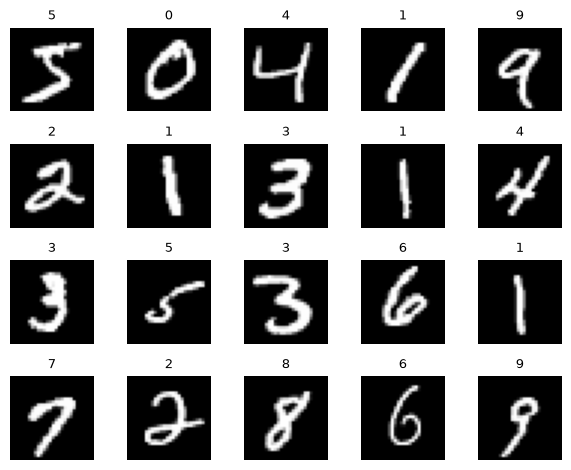

In [3]:
# A grid of representative images with their labels
plot_images(train_x[:20], labels=train_y[:20])

We hold out a validation split from the training data. Model comparisons and any
hyperparameter choices in this notebook use this validation split; the test set is
reserved for the final evaluation only (README, section 12).

In [4]:
train_x_sub, train_y_sub, val_x, val_y = make_train_val_split(train_x, train_y, val_fraction=0.1)
print("train:", train_x_sub.shape, " val:", val_x.shape)

train: (54000, 784)  val: (6000, 784)


## 3. Linear regression baseline

Linear regression was designed to predict a **continuous** number, not a class label.
Applying it to digit classification means treating the digit label as if it were an
ordinary number and minimizing squared error against it — there is nothing in this
objective that "knows" digit $7$ is not numerically close to digit $8$.

We include it anyway because it makes a useful point: a plausible-looking approach
that ignores the actual structure of the problem is still a real baseline, and its
weaknesses are informative.

The closed-form ridge solution is

$$
\theta = (X^{T}X + \lambda I)^{-1}X^{T}Y .
$$

At prediction time the continuous output is rounded to the nearest valid digit.

In [5]:
train_x_bias = np.hstack([np.ones((train_x_sub.shape[0], 1)), train_x_sub])
val_x_bias = np.hstack([np.ones((val_x.shape[0], 1)), val_x])
test_x_bias = np.hstack([np.ones((test_x.shape[0], 1)), test_x])

theta = closed_form(train_x_bias, train_y_sub, lambda_factor=1)
linreg_val_error = compute_test_error_linear(val_x_bias, val_y, theta)
linreg_test_error = compute_test_error_linear(test_x_bias, test_y, theta)

print(f"Linear regression validation error: {linreg_val_error:.4f}")
print(f"Linear regression test error:       {linreg_test_error:.4f}")

Linear regression validation error: 0.7698
Linear regression test error:       0.7719


The error rate is high compared to the methods below. Rounding a continuous
prediction to the nearest digit does not correspond to any meaningful notion of
*margin* or *probability* between classes — it is simply the closest integer. This is
the limitation the next two methods are designed to fix.

## 4. Linear SVM

A linear SVM is trained with the hinge loss, which penalizes points that are not
correctly classified with a sufficient margin, rather than penalizing squared distance
to a numeric target. For multiclass digits we use a **one-vs-rest** strategy: ten
binary hinge-loss classifiers are trained, one per digit, and a test point is assigned
to the class whose classifier is most confident.

In [6]:
svm_pred_val = multi_class_svm(train_x_sub, train_y_sub, val_x)
svm_val_error = compute_test_error_svm(val_y, svm_pred_val)

svm_pred_test = multi_class_svm(train_x_sub, train_y_sub, test_x)
svm_test_error = compute_test_error_svm(test_y, svm_pred_test)

print(f"Linear SVM validation error: {svm_val_error:.4f}")
print(f"Linear SVM test error:       {svm_test_error:.4f}")

Linear SVM validation error: 0.0838
Linear SVM test error:       0.0830


## 5. Softmax regression

Softmax regression produces **ten scores**, one per digit, and converts them into a
probability distribution rather than a single number to round. If $z_0,\ldots,z_9$
are the scores for a given image,

$$
p_k=\frac{\exp(z_k)}{\sum_{j=0}^{9}\exp(z_j)}.
$$

The predicted digit is $\arg\max_k p_k$, but — unlike linear regression's rounded
output, and unlike the SVM's margin — the full vector $p_0,\ldots,p_9$ is itself
meaningful: it expresses how confident the model is, and which digits it considers
plausible alternatives.

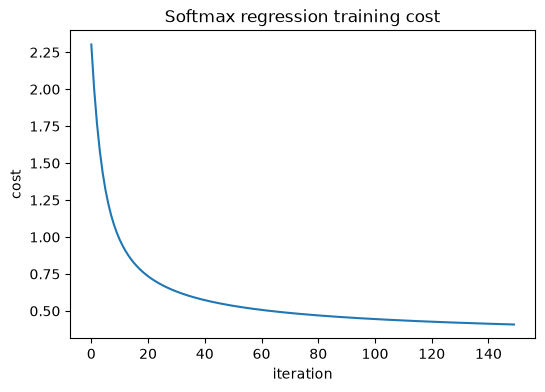

In [7]:
theta_softmax, cost_history = softmax_regression(
    train_x_sub,
    train_y_sub,
    temp_parameter=1,
    alpha=0.3,
    lambda_factor=1e-4,
    k=10,
    num_iterations=150,
)

plt.figure(figsize=(6, 4))
plt.plot(cost_history)
plt.xlabel("iteration")
plt.ylabel("cost")
plt.title("Softmax regression training cost")
plt.show()

In [8]:
softmax_val_error = compute_test_error(val_x, val_y, theta_softmax, temp_parameter=1)
softmax_test_error = compute_test_error(test_x, test_y, theta_softmax, temp_parameter=1)

print(f"Softmax regression validation error: {softmax_val_error:.4f}")
print(f"Softmax regression test error:       {softmax_test_error:.4f}")

Softmax regression validation error: 0.1087
Softmax regression test error:       0.1011


### A single Softmax probability vector

To make the point above concrete, here is the full probability distribution Softmax
regression assigns to one test image, compared with its `argmax` prediction.

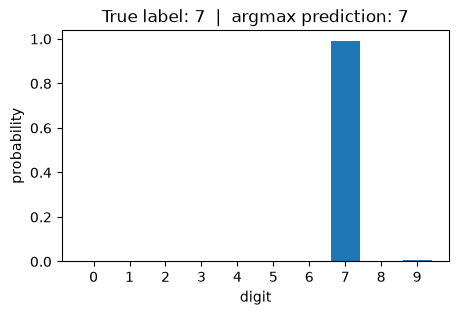

Full probability vector: [0.001 0.    0.    0.003 0.    0.    0.    0.989 0.001 0.007]


In [9]:
example_index = 0
example_x = test_x[example_index : example_index + 1]
probs = compute_probabilities(example_x, theta_softmax, temp_parameter=1).ravel()
predicted_digit = int(np.argmax(probs))

plt.figure(figsize=(5, 3))
plt.bar(range(10), probs)
plt.xticks(range(10))
plt.xlabel("digit")
plt.ylabel("probability")
plt.title(f"True label: {test_y[example_index]}  |  argmax prediction: {predicted_digit}")
plt.show()

print("Full probability vector:", np.round(probs, 3))

Notice that `argmax` alone would discard everything except the single largest bar:
whether the model was nearly certain or only mildly favored one digit over a close
second choice is information the probability vector carries and the hard label does
not.

## 6. Comparison

All three models were trained on the same 784-dimensional pixel vectors, the same
training/validation split, and evaluated on the same held-out test set.

In [10]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "model": ["Linear regression", "Linear SVM", "Softmax regression"],
        "representation": ["raw pixels"] * 3,
        "validation error": [linreg_val_error, svm_val_error, softmax_val_error],
        "test error": [linreg_test_error, svm_test_error, softmax_test_error],
    }
)
comparison

,model,representation,validation error,test error
0,Linear regression,raw pixels,0.769833,0.7719
1,Linear SVM,raw pixels,0.083833,0.0830
2,Softmax regression,raw pixels,0.108667,0.1011


### What this comparison does and does not show

All three methods share the representation (raw pixels), the train/validation split,
and the evaluation set. The differences in error therefore reflect the **learning
rule and loss function**, not the input representation.

This does *not* mean Softmax regression is "the best classifier" in any general
sense — the SVM and linear-regression baseline were trained with their own default
hyperparameters, and no exhaustive tuning was performed. What it does show is that a
loss function connected to the actual classification objective (hinge loss / a
probabilistic log-likelihood) outperforms treating class labels as ordinary numbers.

## 7. Limitations of a linear decision rule on raw pixels

Every model in this notebook makes decisions using a **linear function** of the 784
raw pixel values — SVM and Softmax differ in the loss used to fit that linear
function, but the decision boundary in pixel space is linear (or, for one-vs-rest
SVM/Softmax, a union of such boundaries) in every case.

Two digits that are visually similar but differ mainly in a nonlinear combination of
pixels (e.g. a curved stroke that shifts a few pixels) cannot always be separated by a
hyperplane in raw pixel space. Notebook 02 investigates this directly: does changing
the *representation* — via PCA, an explicit feature map, or a kernel — let a linear
classifier do better without changing anything else?

## Study questions

1. Why is the input dimension 784?
2. What does each Softmax output represent?
3. What information is lost when only `argmax` is retained?